# Example usage of the ofset free koopman MPC

In [1]:
import os
# OpenMP/MKL + PyTorch on macOS segfaults the Jupyter kernel during backward
# unless thread counts are pinned before numpy/torch are imported.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import sys
import numpy as np
#import pandas as pd
import joblib
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch
torch.set_num_threads(1)
from sklearn.preprocessing import StandardScaler

from neuromancer.system import Node, System
from neuromancer.trainer import Trainer
from neuromancer.problem import Problem
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.modules import blocks

# Add 'src' to Python path
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
src_path = os.path.join(project_root, 'src')
sys.path.append(src_path)

import models
import helper
%load_ext autoreload
%autoreload 2

/Users/patrik/miniconda3/envs/kmpc/lib/python3.11/site-packages/mlflow/utils/requirements_utils.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Models imported succesfully
Helper imported succesfully


## Loading a Dataset

## Preparing data for training koopman models

In [2]:
def get_data(train_sim, dev_sim, test_sim, nsteps, bs, scaler, scalerU):
    
    ny = train_sim['Y'].shape[1]
    nu = train_sim['U'].shape[1]
    
    nsim = train_sim['Y'].shape[0]
    nbatch = nsim//nsteps
    length = (nsim//nsteps) * nsteps

    trainX = scaler.transform(train_sim['Y'][:length])
    trainX = trainX.reshape(nbatch, nsteps, ny)
    trainX = torch.tensor(trainX, dtype=torch.float32)
    trainU = scalerU.transform(train_sim['U'][:length])
    trainU = trainU.reshape(nbatch, nsteps, nu)
    trainU = torch.tensor(trainU, dtype=torch.float32)
    train_data = DictDataset({'Y': trainX, 'Y0': trainX[:, 0:1, :],
                              'U': trainU}, name='train')
    train_loader = DataLoader(train_data, batch_size=bs,
                              collate_fn=train_data.collate_fn, shuffle=True)
    
    nsim = dev_sim['Y'].shape[0]
    nbatch = nsim//nsteps
    length = (nsim//nsteps) * nsteps
    
    devX = scaler.transform(dev_sim['Y'][:length])
    devX = devX.reshape(nbatch, nsteps, ny)
    devX = torch.tensor(devX, dtype=torch.float32)
    devU = scalerU.transform(dev_sim['U'][:length])
    devU = devU[:length].reshape(nbatch, nsteps, nu)
    devU = torch.tensor(devU, dtype=torch.float32)
    dev_data = DictDataset({'Y': devX, 'Y0': devX[:, 0:1, :],
                            'U': devU}, name='dev')
    dev_loader = DataLoader(dev_data, batch_size=bs,
                            collate_fn=dev_data.collate_fn, shuffle=True)

    nsim = test_sim['Y'].shape[0]
    nbatch = nsim//nsteps
    length = (nsim//nsteps) * nsteps
    
    testX = scaler.transform(test_sim['Y'][:length])
    testX = testX.reshape(1, nbatch*nsteps, ny)
    testX = torch.tensor(testX, dtype=torch.float32)
    testU = scalerU.transform(test_sim['U'][:length])
    testU = testU.reshape(1, nbatch*nsteps, nu)
    testU = torch.tensor(testU, dtype=torch.float32)
    test_data = {'Y': testX, 'Y0': testX[:, 0:1, :],
                 'U': testU}
    
    trainX = scaler.transform(train_sim['Y'][:length])
    trainX = trainX.reshape(1, nbatch*nsteps, ny)
    trainX = torch.tensor(trainX, dtype=torch.float32)
    trainU = scalerU.transform(train_sim['U'][:length])
    trainU = trainU.reshape(1, nbatch*nsteps, nu)
    trainU = torch.tensor(trainU, dtype=torch.float32)
    train_data_forC = {'Y': trainX, 'Y0': trainX[:, 0:1, :],
                 'U': trainU}

    return train_loader, dev_loader, test_data, train_data_forC

In [3]:
# Load CSTR-separator identification data
# Y: [T1, T2, T3, xB3], U: [Q1, Q2, Q3, F10, F20, Fr]
data = np.load('../data/cstr_separator_ident.npz', allow_pickle=True)
sim = {'Y': np.array(data['Y'], dtype=float), 'U': np.array(data['U'], dtype=float)}

n_train, n_dev = 12960, 2880  # remaining 2160 -> test; 18000 samples, divisible by nsteps=120

# Y already includes range-aware measurement noise from the npz.
if 'noise_sigma' in data.files:
    print('Stored measurement noise (already in Y):')
    for name, s in zip(data['y_names'], np.array(data['noise_sigma'], dtype=float)):
        print(f'  {name}: sigma={s:.4g}')

train = {key: value[:n_train] for key, value in sim.items()}
dev = {key: value[n_train:n_train + n_dev] for key, value in sim.items()}
test = {key: value[n_train + n_dev:] for key, value in sim.items()}

print('Loaded', '../data/cstr_separator_ident.npz')
print('Y', sim['Y'].shape, list(data['y_names']))
print('U', sim['U'].shape, list(data['u_names']))
print('train', train['Y'].shape, 'dev', dev['Y'].shape, 'test', test['Y'].shape)


Stored measurement noise (already in Y):
  T1: sigma=0.4939
  T2: sigma=0.5075
  T3: sigma=0.5558
  xB3: sigma=0.003263
Loaded ../data/cstr_separator_ident.npz
Y (18000, 4) [np.str_('T1'), np.str_('T2'), np.str_('T3'), np.str_('xB3')]
U (18000, 6) [np.str_('Q1'), np.str_('Q2'), np.str_('Q3'), np.str_('F10'), np.str_('F20'), np.str_('Fr')]
train (12960, 4) dev (2880, 4) test (2160, 4)


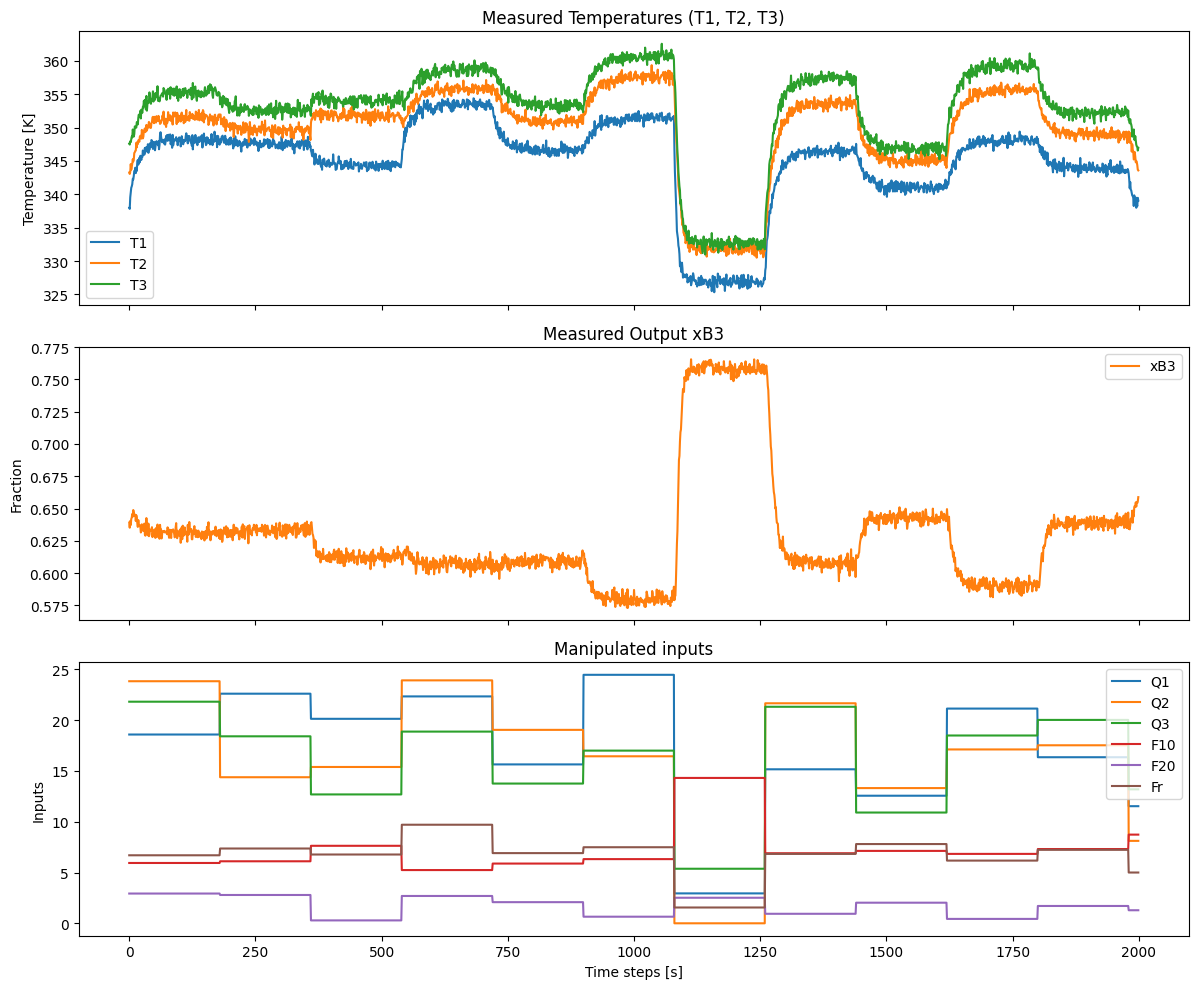

In [4]:
part = 2000
y_names = ["T1", "T2", "T3", "xB3"]
u_names = ["Q1", "Q2", "Q3", "F10", "F20", "Fr"]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot T1, T2, T3 together
for i, name in enumerate(y_names[:-1]):  # T1, T2, T3
    axes[0].plot(sim["Y"][:part, i], label=name)
axes[0].set_ylabel("Temperature [K]")
axes[0].set_title("Measured Temperatures (T1, T2, T3)")
axes[0].legend()

# Plot xB3 separately
axes[1].plot(sim["Y"][:part, 3], label="xB3", color="tab:orange")
axes[1].set_ylabel("Fraction")
axes[1].set_title("Measured Output xB3")
axes[1].legend()

# Plot inputs
for i, name in enumerate(u_names):
    axes[2].plot(sim["U"][:part, i], label=name)
axes[2].set_xlabel("Time steps [s]")
axes[2].set_ylabel("Inputs")
axes[2].set_title("Manipulated inputs")
axes[2].legend()

plt.tight_layout()
plt.show()


In [5]:
nsteps = 120  # HPO-optimal rollout horizon in the loss function
bs = 40       # HPO-optimal minibatch size


In [6]:
# load scalers for scaling the data from saved files
scaler = StandardScaler()
scaler.fit(train['Y'])
joblib.dump(scaler, '../data/scaler_cstr_separator.pkl')

scalerU = StandardScaler()
scalerU.fit(train['U'])
joblib.dump(scalerU, '../data/scalerU_cstr_separator.pkl')


['../data/scalerU_cstr_separator.pkl']

In [7]:
train_loader, dev_loader, test_data, train_data = get_data(train, dev, test, nsteps, bs, scaler, scalerU)


## Creating the model


In [8]:
# model parameters (HPO-optimal; see ../data/model_cstr_separator_noC_optimized_meta.json)
nz = 32
ny = train['Y'].shape[1]
nu = train['U'].shape[1]

encoder_depth = 2
width_mult = 1.0
layers = helper.autoencoder_hsizes(ny, nz, encoder_depth, width_mult)
layers_dec = helper.autoencoder_hsizes(nz, ny, encoder_depth, width_mult)

matrix_C = False


In [9]:
# instantiate output encoder neural net f_y
f_y = blocks.MLP(
    ny,
    nz,
    bias=True,
    linear_map=torch.nn.Linear,
    nonlin=torch.nn.ELU,
    hsizes=layers,
)
# initial condition encoder
encode_Y0 = Node(f_y, ['Y0'], ['x'], name='encoder_Y0')
# observed trajectory encoder
encode_Y = Node(f_y, ['Y'], ['x_latent'], name='encoder_Y')

In [10]:
# instantiate input encoder net f_u, representing the B matrix in the linear system
f_u = torch.nn.Linear(nu, nz, bias=False)
# initial condition encoder
encode_U = Node(f_u, ['U'], ['u_latent'], name='encoder_U')

In [11]:
# instantiate state decoder neural net f_y_inv
if not matrix_C:
    f_y_inv = blocks.MLP(nz, ny, bias=True,
                    linear_map=torch.nn.Linear,
                    nonlin=torch.nn.ELU,
                    hsizes=layers_dec)
elif matrix_C:
    f_y_inv = torch.nn.Linear(nz, ny, bias=False)
else:
    raise ValueError('matrix_C must be boolean')

# predicted trajectory decoder
decode_y = Node(f_y_inv, ['x'], ['yhat'], name='decoder_y')

In [12]:
# representing matrix A in the linear system
K = torch.nn.Linear(nz, nz, bias=False)

In [13]:
# symbolic Koopman model with control inputs
Koopman = Node(helper.PredictionWControl(K), ['x', 'u_latent'], ['x'], name='K')

# latent Koopmann rollout
dynamics_model = System([Koopman], name='Koopman', nsteps=nsteps)

In [14]:
# put all nodes of the Koopman model together in a list of nodes
nodes = [encode_Y0, encode_Y, encode_U, dynamics_model, decode_y]

### Define Koopman system identification loss function terms

In [15]:
# variables
Y = variable("Y")  # observed
yhat = variable('yhat')  # predicted output
x_latent = variable('x_latent')  # encoded output trajectory in the latent space
u_latent = variable('u_latent')  # encoded input trajectory in the latent space
x = variable('x')  # Koopman latent space trajectory

xu_latent = x_latent + u_latent  # latent state trajectory

# HPO-optimal loss weights
y_loss_w = 13.296
x_loss_w = 3.344
onestep_loss_w = 1.0
recon_loss_w = 1.746

# output trajectory tracking loss
y_loss = y_loss_w * (yhat[:, 1:-1, :] == Y[:, 1:, :]) ^ 2
y_loss.name = "y_loss"

# one-step tracking loss
onestep_loss = onestep_loss_w * (yhat[:, 1, :] == Y[:, 1, :])^2
onestep_loss.name = "onestep_loss"

# reconstruction loss
reconstruction_loss = recon_loss_w * (yhat[:, 0, :] == Y[:, 0, :])^2
reconstruction_loss.name = "reconstruction_loss"

# latent trajectory tracking loss
x_loss = x_loss_w * (x[:, 1:-1, :] == xu_latent[:, 1:, :]) ^ 2
x_loss.name = "x_loss"


### Construct System learning problem

In [16]:
# aggregate list of objective terms and constraints
objectives = [y_loss, x_loss, onestep_loss, reconstruction_loss]

# create constrained optimization loss
loss = PenaltyLoss(objectives, constraints=[])

# construct constrained optimization problem
problem = Problem(nodes, loss)

In [17]:
problem.nodes

ModuleList(
  (0): encoder_Y0(Y0) -> x
  (1): encoder_Y(Y) -> x_latent
  (2): encoder_U(U) -> u_latent
  (3): System(
    (nodes): ModuleList(
      (0): K(x, u_latent) -> x
    )
  )
  (4): decoder_y(x) -> yhat
)

### Solve the problem

In [18]:
from neuromancer.trainer import Callback

class PrintCallback(Callback):
    def end_eval(self, trainer, output):
        if trainer.current_epoch % trainer.epoch_verbose == 0:
            train_loss = output.get('mean_train_loss', output.get('train_loss', 'N/A'))
            dev_loss = output.get('mean_dev_loss', output.get('dev_loss', 'N/A'))
            print(f"epoch: {trainer.current_epoch}  "
                  f"train_loss: {train_loss}  "
                  f"dev_loss: {dev_loss}")

torch.manual_seed(2843)
np.random.seed(2843)

optimizer = torch.optim.Adam(problem.parameters(), lr=7.531e-4)

trainer = Trainer(
    problem,
    train_loader,
    dev_loader,
    test_data,
    optimizer,
    callback=PrintCallback(),
    patience=300,
    warmup=100,
    epochs=3000,
    eval_metric="dev_loss",
    train_metric="train_loss",
    dev_metric="dev_loss",
    test_metric="dev_loss",
)


In [19]:
# train

best_model = trainer.train()
problem.load_state_dict(best_model)


epoch: 0  train_loss: 19.007827758789062
epoch: 0  train_loss: 19.007827758789062  dev_loss: 24.961326599121094
epoch: 1  train_loss: 17.660425186157227
epoch: 1  train_loss: 17.660425186157227  dev_loss: 23.459823608398438
epoch: 2  train_loss: 16.266244888305664
epoch: 2  train_loss: 16.266244888305664  dev_loss: 22.105710983276367
epoch: 3  train_loss: 14.512141227722168
epoch: 3  train_loss: 14.512141227722168  dev_loss: 20.85869598388672
epoch: 4  train_loss: 13.688568115234375
epoch: 4  train_loss: 13.688568115234375  dev_loss: 19.711055755615234
epoch: 5  train_loss: 12.68288803100586
epoch: 5  train_loss: 12.68288803100586  dev_loss: 18.655193328857422
epoch: 6  train_loss: 12.22718334197998
epoch: 6  train_loss: 12.22718334197998  dev_loss: 17.697376251220703
epoch: 7  train_loss: 11.745219230651855
epoch: 7  train_loss: 11.745219230651855  dev_loss: 16.829147338867188
epoch: 8  train_loss: 10.926204681396484
epoch: 8  train_loss: 10.926204681396484  dev_loss: 16.0165309906005

<All keys matched successfully>

### Saving model and evaluation of the training

In [20]:
# save model
torch.save(best_model, "../data/model_cstr_separator_C_" + str(matrix_C) + ".pth")

# pull matrices
A = K.weight.detach().numpy()
B = f_u.weight.detach().numpy()
if matrix_C:
    C = f_y_inv.weight.detach().numpy()
    
elif not matrix_C:
    # get approximate C matrix from training data
    problem.nodes[3].nsteps = train_data['Y'].shape[1]
    train_outputs = problem.step(train_data)

    Y = train_data['Y'].reshape(-1, ny).detach().numpy()
    Z = train_outputs['x'][:,:-1,:].detach().numpy().reshape(-1, nz)
    rankZ = np.linalg.matrix_rank(Z)
    if rankZ < nz:
        print('Rank deficient Z matrix, can result in bad fitted C matrix!')
        print(f'Rank of Z: {rankZ}, nz: {nz}')
    C, residuals, rank, s = np.linalg.lstsq(Z, Y, rcond=None)
    C = C.T

else:
    raise ValueError('matrix_C must be boolean')


Rank deficient Z matrix, can result in bad fitted C matrix!
Rank of Z: 23, nz: 32


In [21]:
from numpy.linalg import matrix_rank

# Compute the controllability matrix
n_states = A.shape[0]
controllability_matrix = np.hstack([np.linalg.matrix_power(A, i) @ B for i in range(n_states)])

# Check the rank of the controllability matrix
controllability_rank = matrix_rank(controllability_matrix)

print(f"Controllability Matrix Rank: {controllability_rank}")
print(f"System is {'controllable' if controllability_rank == n_states else 'not controllable'}")

# Compute the observability matrix
observability_matrix = np.vstack([C @ np.linalg.matrix_power(A, i) for i in range(n_states)])

# Check the rank of the observability matrix
observability_rank = matrix_rank(observability_matrix)

print(f"Observability Matrix Rank: {observability_rank}")
print(f"System is {'observable' if observability_rank == n_states else 'not observable'}")

Controllability Matrix Rank: 32
System is controllable
Observability Matrix Rank: 31
System is not observable


In [22]:
np.save('../data/A_cstr_separator_C_' + str(matrix_C) + '.npy', A)
np.save('../data/B_cstr_separator_C_' + str(matrix_C) + '.npy', B)
np.save('../data/C_cstr_separator_C_' + str(matrix_C) + '.npy', C)


In [23]:
# update the rollout length based on the test data
problem.nodes[3].nsteps = test_data['Y'].shape[1]

In [24]:
# do the prediction
test_outputs = problem.step(test_data)

pred_traj = test_outputs['yhat'][:, 1:-1, :].detach().numpy().reshape(-1, ny).T
true_traj = test_data['Y'][:, 1:pred_traj.shape[1]+1, ].detach().numpy().reshape(-1, ny).T
input_traj = test_data['U'].detach().numpy().reshape(-1, nu).T
pred_x = test_outputs['x'][:, 1:-1, :].detach().numpy().reshape(-1, nz).T

In [25]:
pred_traj_C = np.dot(C, pred_x)

In [26]:
x_mean = np.mean(pred_x, axis=1, keepdims=True)
x_med = np.median(pred_x, axis=1, keepdims=True)

In [27]:
def get_y_from_x(problem, x: np.ndarray) -> np.ndarray:
    y = problem.nodes[4]({"x": torch.from_numpy(x.T).float()})
    return y["yhat"].detach().numpy().reshape(1, -1)

In [28]:
J = helper.evaluate_jacobian(
    problem.nodes[4],
    torch.from_numpy(x_mean[:,0]).float(),
)
# Get all latent states from training data
x_train = train_outputs['x'].detach().numpy().reshape(-1, nz)

# Evaluate Jacobian for each latent state
J_all = np.stack([
    helper.evaluate_jacobian(problem.nodes[4], torch.from_numpy(xi).float())
    for xi in x_train
])

bias_all = np.stack([
    get_y_from_x(problem, xi.reshape(-1,1))
    for xi in x_train
])

# Compute mean Jacobian
J_mean = np.mean(J_all, axis=0)
print("Mean Jacobian J_mean:\n", J_mean) # mean bias?

bias_mean = np.mean(bias_all, axis=0)
print("Mean Bias:\n", bias_mean)


pred_traj_J = np.dot(J_mean, pred_x - x_mean) #+ bias_mean.T

Mean Jacobian J_mean:
 [[ 0.16551101 -0.2277879  -0.1296039  -0.04849752  0.22950687 -0.20674793
  -0.16122599  0.12022784  0.05044524  0.10904053  0.2426138   0.15379554
  -0.24970251  0.02514826  0.0571933   0.04961419 -0.36233142  0.19627514
   0.13306645 -0.1262526  -0.16860111 -0.12669477 -0.10220169 -0.05822546
  -0.15015838  0.14510621 -0.12547903 -0.4026778   0.03106745  0.0615867
   0.08668809  0.55094296]
 [ 0.15680945  0.11001694  0.01130539  0.12075378  0.08508791 -0.04242672
  -0.07199308  0.03900767  0.21192752  0.02363518  0.13871486  0.17488211
  -0.13745227  0.17210236  0.07688738  0.11599645 -0.12108605  0.10296112
  -0.09476656 -0.12269528  0.05334683 -0.02160771  0.02657216  0.09557064
   0.17562181  0.20503543 -0.03754257 -0.11752882 -0.03211137  0.11341336
   0.02509936  0.1570603 ]
 [ 0.18360952  0.09214355 -0.00304856  0.08083311  0.12699565 -0.14759219
  -0.07575095  0.07126229  0.09423365  0.05330324  0.13941051  0.13011356
  -0.20855486  0.16281231  0.0601411

In [29]:
x_lin = np.zeros((nz,1))
J = helper.evaluate_jacobian(
    problem.nodes[4],
    torch.from_numpy(x_lin[:,0]).float(),
)

bias = get_y_from_x(problem, x_lin)
pred_traj_J = np.dot(J, pred_x - x_lin) + bias.T

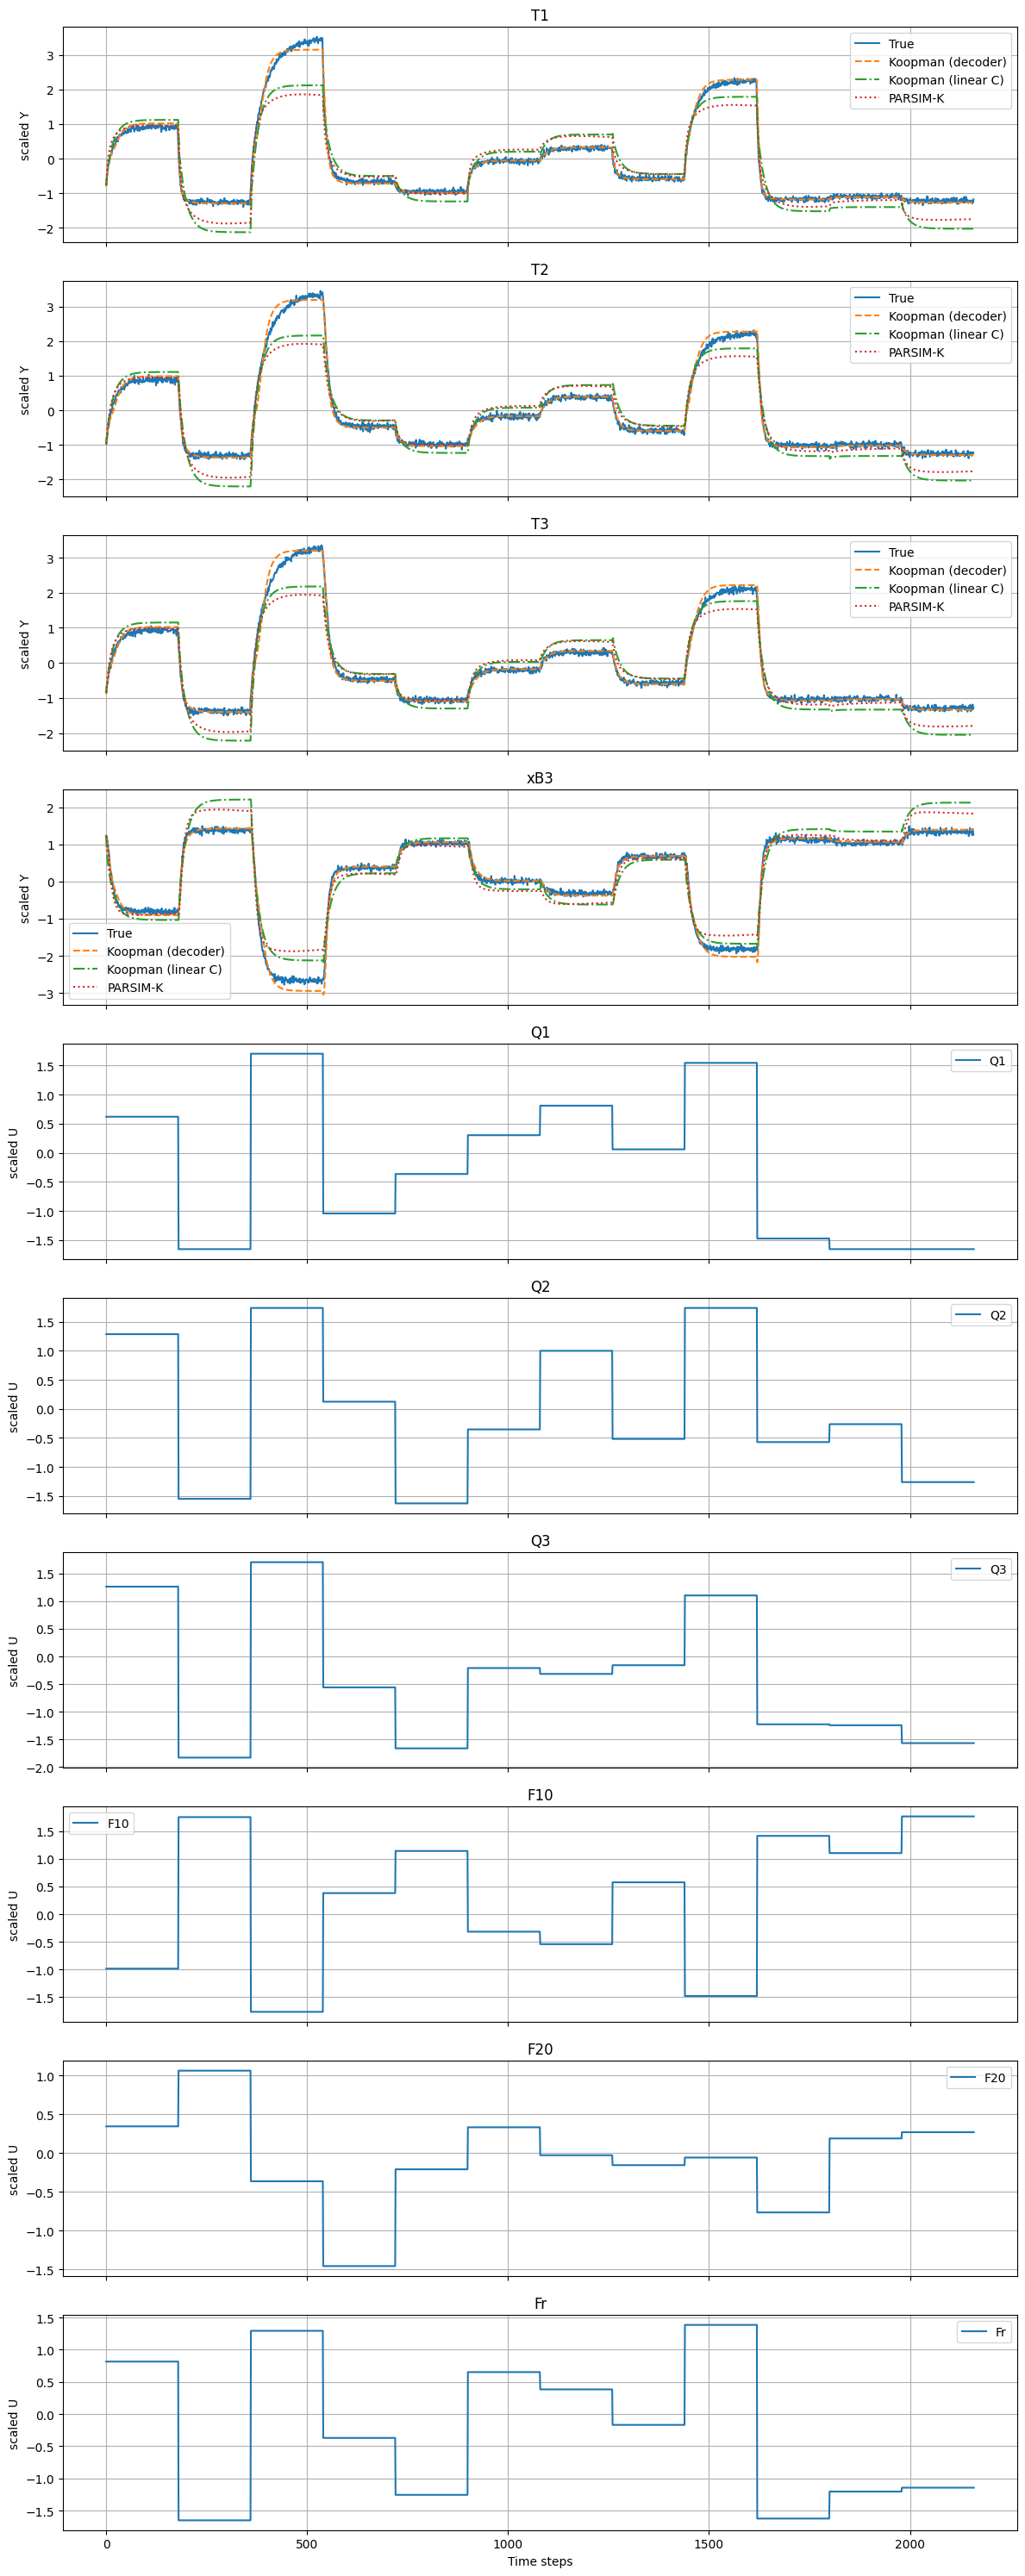

In [30]:
def ss_lsim(A, B, C, D, U, x0):
    """Process-form rollout: y_k = C x_k + D u_k, x_{k+1} = A x_k + B u_k. U is (nu, N)."""
    N = U.shape[1]
    y = np.zeros((C.shape[0], N))
    x = np.asarray(x0, dtype=float).reshape(-1)
    for k in range(N):
        uk = U[:, k]
        y[:, k] = C @ x + D @ uk
        x = A @ x + B @ uk
    return y


N = min(true_traj.shape[1], pred_traj.shape[1], max(input_traj.shape[1] - 1, 1))
true_cmp = true_traj[:, :N]
pred_nl = pred_traj[:, :N]
U_eval = input_traj[:, 1:1 + N]
y0 = true_cmp[:, 0:1]

A_sippy = np.load('../data/A_cstr_separator_parsimK.npy')
B_sippy = np.load('../data/B_cstr_separator_parsimK.npy')
C_sippy = np.load('../data/C_cstr_separator_parsimK.npy')
D_sippy = np.load('../data/D_cstr_separator_parsimK.npy')
pred_sippy = ss_lsim(A_sippy, B_sippy, C_sippy, D_sippy, U_eval, np.linalg.pinv(C_sippy) @ y0)

A_linC = np.load('../data/A_cstr_separator_C_True.npy')
B_linC = np.load('../data/B_cstr_separator_C_True.npy')
C_linC = np.load('../data/C_cstr_separator_C_True.npy')
D_linC = np.zeros((C_linC.shape[0], B_linC.shape[1]))
pred_linC = ss_lsim(A_linC, B_linC, C_linC, D_linC, U_eval, np.linalg.pinv(C_linC) @ y0)

y_plot_names = list(data['y_names']) if 'data' in dir() else [f'y{i+1}' for i in range(ny)]
u_plot_names = list(data['u_names']) if 'data' in dir() else [f'u{i+1}' for i in range(nu)]

fig, axs = plt.subplots(ny + nu, 1, figsize=(12, 3 * (ny + nu)), sharex=True)

for i in range(ny):
    axs[i].plot(true_cmp[i], label='True', linestyle='-')
    axs[i].plot(pred_nl[i], label='Koopman (decoder)', linestyle='--')
    axs[i].plot(pred_linC[i], label='Koopman (linear C)', linestyle='-.')
    axs[i].plot(pred_sippy[i], label='PARSIM-K', linestyle=':')
    axs[i].set_title(str(y_plot_names[i]))
    axs[i].set_ylabel('scaled Y')
    axs[i].legend()
    axs[i].grid()

for i in range(nu):
    axs[ny + i].plot(input_traj[i], label=str(u_plot_names[i]), linestyle='-')
    axs[ny + i].set_title(str(u_plot_names[i]))
    axs[ny + i].set_ylabel('scaled U')
    axs[ny + i].legend()
    axs[ny + i].grid()

axs[-1].set_xlabel('Time steps')
plt.tight_layout()
plt.show()


In [31]:
models = {
    'Koopman (decoder)': pred_nl,
    'Koopman (linear C)': pred_linC,
    'PARSIM-K': pred_sippy,
}

print(f'Horizon N = {N} (scaled test outputs)\n')
print(f'{"channel":<8} {"model":<22} {"MAE":>12} {"MSE":>12}')
print('-' * 56)
for i, name in enumerate(y_plot_names):
    for model_name, yhat in models.items():
        err = true_cmp[i] - yhat[i]
        mae = np.mean(np.abs(err))
        mse = np.mean(err ** 2)
        print(f'{str(name):<8} {model_name:<22} {mae:12.6f} {mse:12.6f}')
    print()

print('Overall (all channels, all time)')
print(f'{"model":<22} {"MAE":>12} {"MSE":>12}')
print('-' * 48)
for model_name, yhat in models.items():
    err = true_cmp - yhat
    print(f'{model_name:<22} {np.mean(np.abs(err)):12.6f} {np.mean(err ** 2):12.6f}')


Horizon N = 2159 (scaled test outputs)

channel  model                           MAE          MSE
--------------------------------------------------------
T1       Koopman (decoder)          0.067926     0.009784
T1       Koopman (linear C)         0.398611     0.239449
T1       PARSIM-K                   0.339548     0.222976

T2       Koopman (decoder)          0.078123     0.012053
T2       Koopman (linear C)         0.369616     0.207706
T2       PARSIM-K                   0.316252     0.188574

T3       Koopman (decoder)          0.076638     0.012487
T3       Koopman (linear C)         0.348551     0.184787
T3       PARSIM-K                   0.297961     0.165450

xB3      Koopman (decoder)          0.082687     0.013272
xB3      Koopman (linear C)         0.313048     0.150214
xB3      PARSIM-K                   0.260876     0.112283

Overall (all channels, all time)
model                           MAE          MSE
------------------------------------------------
Koopman (decod

In [32]:
# Calculate variance of mismatch (error) between test data and predicted data
var_error_pred = np.var(true_traj - pred_traj, axis=1)
var_error_pred_C = np.var(true_traj - pred_traj_C, axis=1)
var_error_pred_J = np.var(true_traj - pred_traj_J, axis=1)

print(f'Variance of mismatch (True - Predicted): {var_error_pred}')
print(f'Variance of mismatch (True - Predicted C): {var_error_pred_C}')
print(f'Variance of mismatch (True - Predicted J): {var_error_pred_J}')



Variance of mismatch (True - Predicted): [0.00976769 0.01205255 0.01227067 0.01277294]
Variance of mismatch (True - Predicted C): [0.3108958  0.27619636 0.23628291 0.16763884]
Variance of mismatch (True - Predicted J): [0.25550138 0.19880063 0.15593617 0.10513055]


In [33]:
# Calculate mean squared error (MSE) of all test predictions
mse_pred = np.mean((true_traj - pred_traj) ** 2)
mse_pred_C = np.mean((true_traj - pred_traj_C) ** 2)
mse_pred_J = np.mean((true_traj - pred_traj_J) ** 2)

print(f'MSE of predicted trajectory: {mse_pred}')
print(f'MSE of predicted trajectory C: {mse_pred_C}')
print(f'MSE of predicted trajectory J: {mse_pred_J}')


MSE of predicted trajectory: 0.011898905038833618
MSE of predicted trajectory C: 0.24813894927501678
MSE of predicted trajectory J: 0.3313907085621273


In [34]:
# Define lower and upper bounds for true_traj values
lower_bound = -0.50
upper_bound = 0.50

# Create mask for values within the specified range
mask = (true_traj >= lower_bound) & (true_traj <= upper_bound)

# Compute MAE only for masked values
mae_pred_masked = [np.mean(np.abs(true_traj[i][mask[i]] - pred_traj[i][mask[i]])) for i in range(true_traj.shape[0])]
mae_pred_C_masked = [np.mean(np.abs(true_traj[i][mask[i]] - pred_traj_C[i][mask[i]])) for i in range(true_traj.shape[0])]
mae_pred_J_masked = [np.mean(np.abs(true_traj[i][mask[i]] - pred_traj_J[i][mask[i]])) for i in range(true_traj.shape[0])]

print(f'Masked MAE of predicted trajectory: {mae_pred_masked}')
print(f'Masked MAE of predicted trajectory C: {mae_pred_C_masked}')
print(f'Masked MAE of predicted trajectory J: {mae_pred_J_masked}')

Masked MAE of predicted trajectory: [np.float32(0.05560867), np.float32(0.06217936), np.float32(0.061217308), np.float32(0.057928856)]
Masked MAE of predicted trajectory C: [np.float32(0.2976882), np.float32(0.26937917), np.float32(0.2512867), np.float32(0.2646885)]
Masked MAE of predicted trajectory J: [np.float64(0.10117975220794673), np.float64(0.08566124148752542), np.float64(0.06950046341907175), np.float64(0.05571422465644737)]


In [35]:
J_mean

array([[ 0.16551101, -0.2277879 , -0.1296039 , -0.04849752,  0.22950687,
        -0.20674793, -0.16122599,  0.12022784,  0.05044524,  0.10904053,
         0.2426138 ,  0.15379554, -0.24970251,  0.02514826,  0.0571933 ,
         0.04961419, -0.36233142,  0.19627514,  0.13306645, -0.1262526 ,
        -0.16860111, -0.12669477, -0.10220169, -0.05822546, -0.15015838,
         0.14510621, -0.12547903, -0.4026778 ,  0.03106745,  0.0615867 ,
         0.08668809,  0.55094296],
       [ 0.15680945,  0.11001694,  0.01130539,  0.12075378,  0.08508791,
        -0.04242672, -0.07199308,  0.03900767,  0.21192752,  0.02363518,
         0.13871486,  0.17488211, -0.13745227,  0.17210236,  0.07688738,
         0.11599645, -0.12108605,  0.10296112, -0.09476656, -0.12269528,
         0.05334683, -0.02160771,  0.02657216,  0.09557064,  0.17562181,
         0.20503543, -0.03754257, -0.11752882, -0.03211137,  0.11341336,
         0.02509936,  0.1570603 ],
       [ 0.18360952,  0.09214355, -0.00304856,  0.0808

In [36]:
C

array([[ 10.232205  ,  17.852278  ,  -6.441708  ,  -3.8890915 ,
         -6.1820483 ,  17.392153  ,   3.184132  ,   8.76484   ,
         -0.23077588, -14.703172  ,  12.290589  ,   5.0510244 ,
          2.1748655 , -13.870764  ,  -7.5975065 ,  -4.6718316 ,
        -14.829857  , -16.986433  ,   9.19553   ,   1.8392833 ,
          3.2818427 ,   6.9170337 ,  -3.7701178 ,   5.7849607 ,
          2.890586  ,   2.1574783 ,  -3.5199    ,   1.207563  ,
        -16.63777   , -14.853948  ,   2.7508128 ,   0.606046  ],
       [  4.707649  ,  14.961688  ,  -2.04779   ,  -5.697375  ,
         -1.2030779 ,  11.645709  ,  -0.46318448,   4.914559  ,
          1.9507958 , -10.857678  ,  11.561605  ,  10.411059  ,
          5.3800473 , -13.7703705 ,  -1.1055113 ,  -4.5857115 ,
        -10.232024  , -14.268073  ,   7.3366923 ,   4.8189263 ,
          3.8750691 ,   5.4670334 ,  -3.5652676 ,   5.8967953 ,
          4.6964235 ,   2.638481  ,  -0.4477511 ,  -1.1912273 ,
        -12.837006  , -10.142916  ,  -0

In [37]:
# mse C-J
mse_C_J = np.mean((C - J_mean) ** 2)
print("Mean Squared Error between C and J_mean:\n", mse_C_J)
# mse C-J
mse_C_J = np.mean((C - J) ** 2)
print("Mean Squared Error between C and J:\n", mse_C_J)

Mean Squared Error between C and J_mean:
 72.70114
Mean Squared Error between C and J:
 72.60722


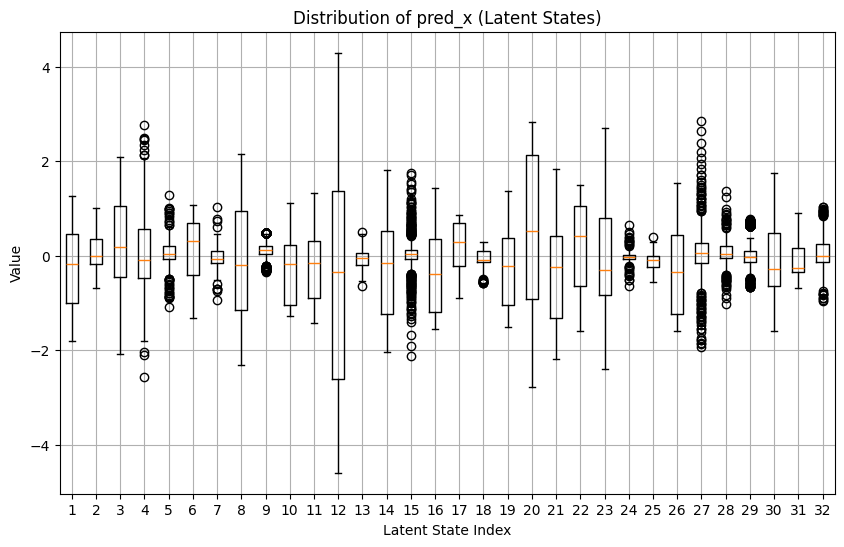

In [38]:
plt.figure(figsize=(10, 6))
plt.boxplot(pred_x.T)
plt.title('Distribution of pred_x (Latent States)')
plt.xlabel('Latent State Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

## Open-loop simulation with zero inputs


In [39]:
# Set up open-loop simulation parameters
n_sim_steps = 500

# Use mean of training data as initial condition (in original scale)
Y0_mean = np.mean(train['Y'], axis=0).reshape(1, 1, ny)

# Scale the initial condition
Y0_scaled = scaler.transform(Y0_mean.reshape(1, -1)).reshape(1, 1, ny)
Y0_tensor = torch.tensor(Y0_scaled, dtype=torch.float32)

# Create zero inputs for all simulation steps (in original scale)
U_scaled = np.zeros((1, n_sim_steps, nu))
U_tensor = torch.tensor(U_scaled, dtype=torch.float32)

# Create dummy Y vector as zeros for all simulation steps
Y_dummy_scaled = np.zeros((1, n_sim_steps, ny))
Y_dummy_tensor = torch.tensor(Y_dummy_scaled, dtype=torch.float32)

# Create simulation data dictionary, adding dummy Y
sim_data = {
    'Y0': Y0_tensor,
    'U': U_tensor,
    'Y': Y_dummy_tensor
}

print(f"Initial condition (scaled): {Y0_scaled.flatten()}")
print(f"Input shape: {U_tensor.shape}")
print(f"Dummy Y shape: {Y_dummy_tensor.shape}")
print(f"Simulation will run for {n_sim_steps} steps")


Initial condition (scaled): [0. 0. 0. 0.]
Input shape: torch.Size([1, 500, 6])
Dummy Y shape: torch.Size([1, 500, 4])
Simulation will run for 500 steps


In [40]:
# Update the rollout length for simulation
problem.nodes[3].nsteps = n_sim_steps

# Run the open-loop simulation
sim_outputs = problem.step(sim_data)

# Extract predicted outputs
sim_yhat = sim_outputs['yhat'][:, 1:-1, :].detach().numpy().reshape(-1, ny)

# Unscale the outputs to original scale
sim_yhat_unscaled = scaler.inverse_transform(sim_yhat)

# Extract latent states
sim_x = sim_outputs['x'][:, 1:-1, :].detach().numpy().reshape(-1, nz)

print(f"Simulation completed!")
print(f"Output shape: {sim_yhat_unscaled.shape}")
print(f"Latent state shape: {sim_x.shape}")


Simulation completed!
Output shape: (499, 4)
Latent state shape: (499, 32)


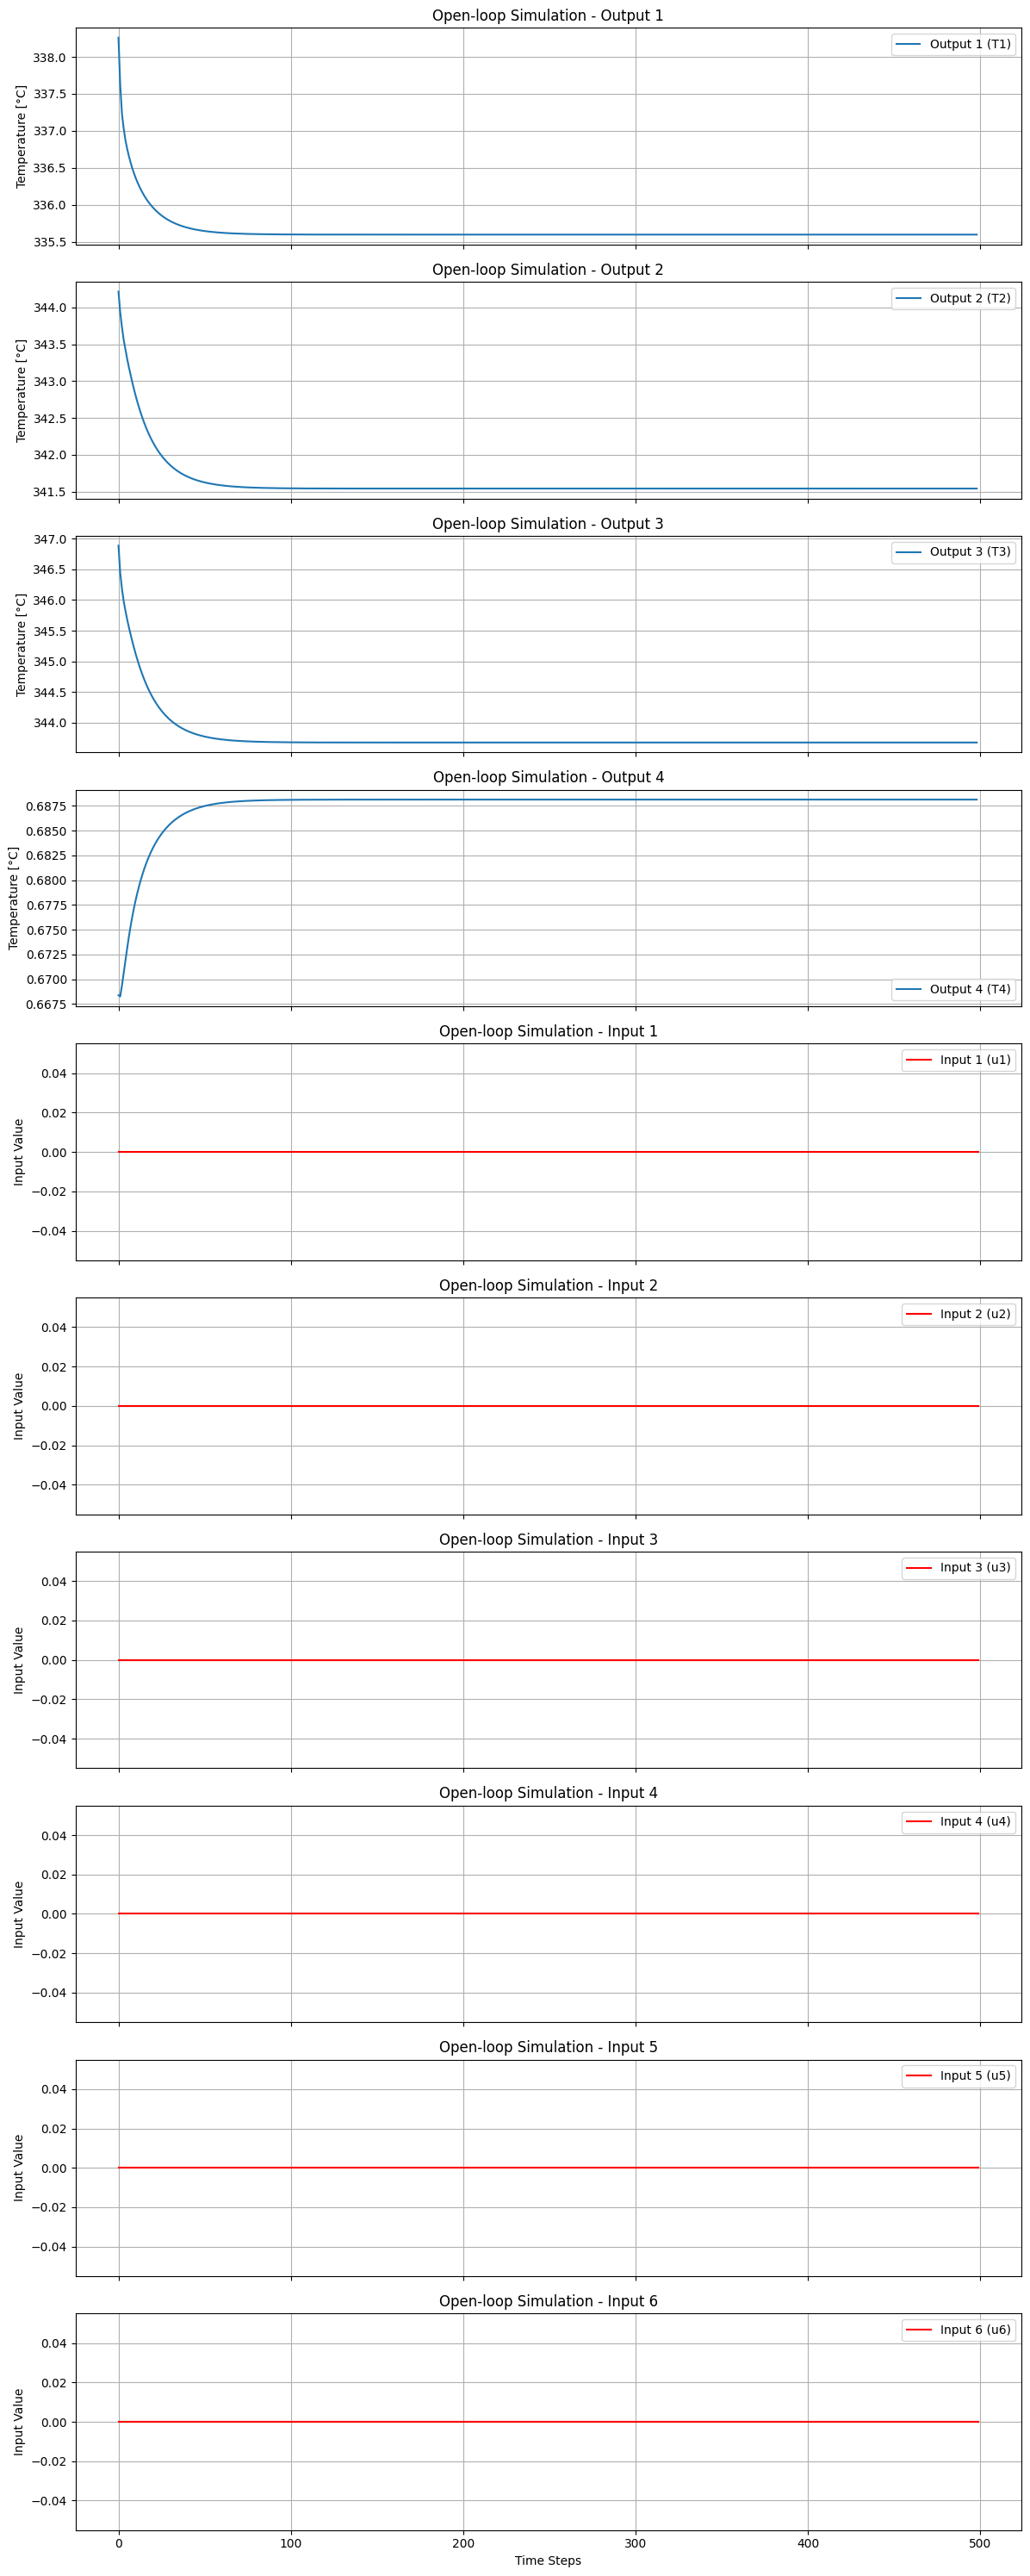


Simulation Statistics:
Final output values: [335.5964     341.5423     343.67786      0.68813664]
Output range: [[335.5964    341.5423    343.67786     0.6682501], [338.25964    344.21426    346.88657      0.68813664]]
Output mean: [335.64532    341.6181     343.76505      0.68752646]
Output std: [0.22637394 0.30622464 0.3536527  0.00250426]


In [41]:
# Plot the open-loop simulation results
fig, axs = plt.subplots(ny + nu, 1, figsize=(12, 3 * (ny + nu)), sharex=True)

# Plot outputs
for i in range(ny):
    axs[i].plot(sim_yhat_unscaled[:, i], label=f'Output {i + 1} (T{i+1 if i < 3 else i+1})', linewidth=1.5)
    axs[i].set_title(f'Open-loop Simulation - Output {i + 1}')
    axs[i].set_ylabel('Temperature [°C]')
    axs[i].legend()
    axs[i].grid(True)

# Plot inputs (zeros)
for i in range(nu):
    axs[ny + i].plot(U_scaled[0, :, i], label=f'Input {i + 1} (u{i+1})', linewidth=1.5, color='red')
    axs[ny + i].set_title(f'Open-loop Simulation - Input {i + 1}')
    axs[ny + i].set_ylabel('Input Value')
    axs[ny + i].legend()
    axs[ny + i].grid(True)

# Add x-axis label to the last subplot
axs[-1].set_xlabel('Time Steps')

plt.tight_layout()
plt.show()

# Print some statistics
print("\nSimulation Statistics:")
print(f"Final output values: {sim_yhat_unscaled[-1, :]}")
print(f"Output range: [{sim_yhat_unscaled.min(axis=0)}, {sim_yhat_unscaled.max(axis=0)}]")
print(f"Output mean: {sim_yhat_unscaled.mean(axis=0)}")
print(f"Output std: {sim_yhat_unscaled.std(axis=0)}")
